# ML Project

Stroke prediction model

## **Setup** (Using Google colab fo this project)

In [2]:
!pip install -q autogluon.tabular[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 721.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from google.colab import files
uploaded = files.upload()  #upload the data file

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


### Imports

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor


## **EDA**

### Import the data and load it

In [5]:
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(df.shape)

print("_"*100)

df.head()

(5110, 12)
____________________________________________________________________________________________________


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Exploring the data


In [6]:
print("-- Target Balance --\n")
print(df['stroke'].value_counts())

print('\n\n')

print(df['stroke'].value_counts(normalize=True)) #Check data imbalance
print('\n'+'-'*100+'\n')
print("-- Missing values --\n")
print(df.isna().sum()) #check for null values for all columns




-- Target Balance --

stroke
0    4861
1     249
Name: count, dtype: int64



stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

----------------------------------------------------------------------------------------------------

-- Missing values --

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


### Data quality checks

In [7]:
print("-- Duplicates --\n")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate IDs:  {df['id'].duplicated().sum()}")

print('\n'+'-'*100+'\n')

print("-- Smoking status breakdown --\n")
print(df['smoking_status'].value_counts())
print('\n')
print(df['smoking_status'].value_counts(normalize=True).round(4))

print('\n'+'-'*100+'\n')

print("-- Edge cases & outliers --\n")
print(f"Rows with age < 1 (infants): {(df['age'] < 1).sum()}")
print(f"Max BMI: {df['bmi'].max()}  (rows with BMI > 60: {(df['bmi'] > 60).sum()})")
print(f"Max glucose: {df['avg_glucose_level'].max():.1f}")

-- Duplicates --

Duplicate rows: 0
Duplicate IDs:  0

----------------------------------------------------------------------------------------------------

-- Smoking status breakdown --

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


smoking_status
never smoked       0.3703
Unknown            0.3022
formerly smoked    0.1732
smokes             0.1544
Name: proportion, dtype: float64

----------------------------------------------------------------------------------------------------

-- Edge cases & outliers --

Rows with age < 1 (infants): 43
Max BMI: 97.6  (rows with BMI > 60: 13)
Max glucose: 271.7


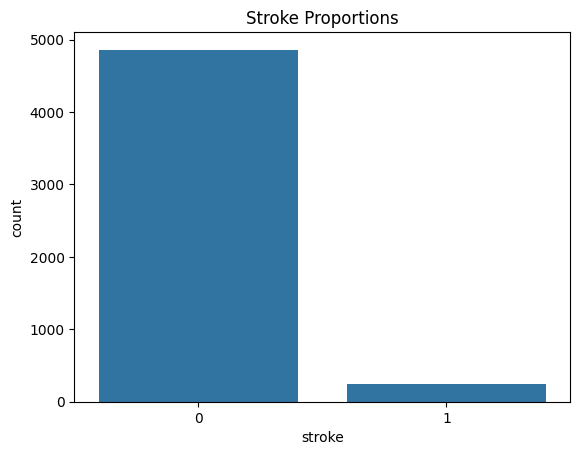

In [8]:
import seaborn as sns

sns.countplot(x='stroke', data=df)
plt.title("Stroke Proportions")

plt.show()

Does higher age lead to more strokes?

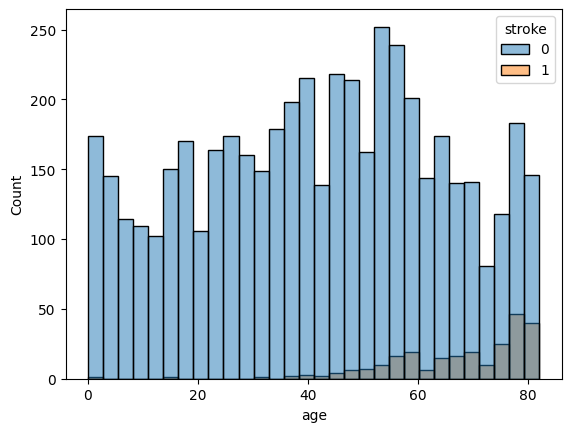

In [9]:
sns.histplot(data=df, x='age', hue='stroke', bins=30, kde=False)
plt.show()


### Distributions

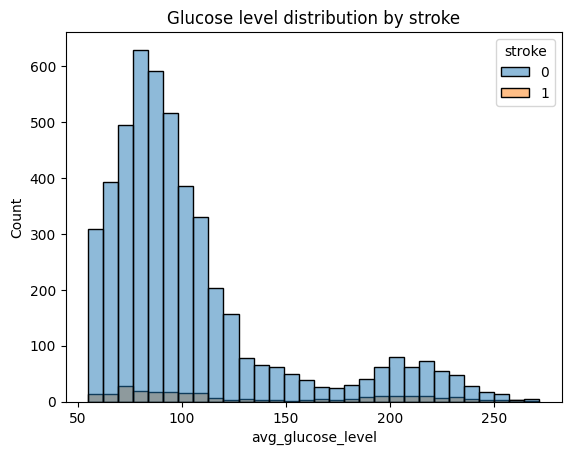

In [10]:
sns.histplot(data=df, x='avg_glucose_level', hue='stroke', bins=30)
plt.title('Glucose level distribution by stroke')
plt.show()



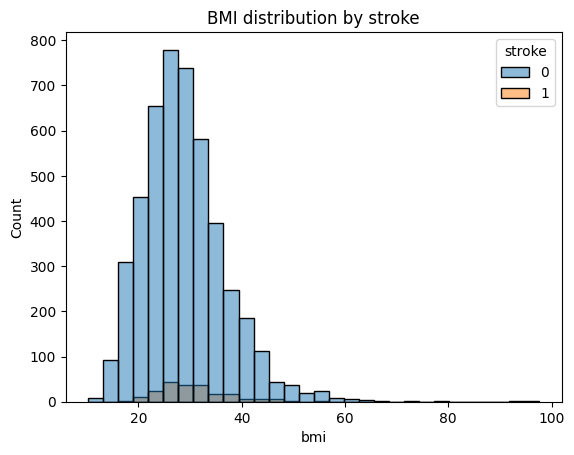

In [11]:
sns.histplot(data=df, x='bmi', hue='stroke', bins=30)
plt.title('BMI distribution by stroke')
plt.show()



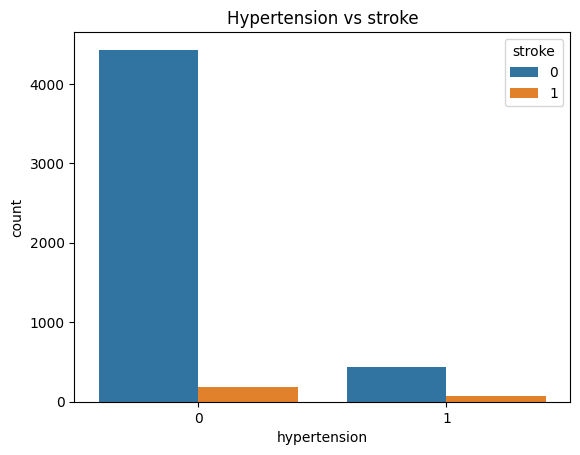

In [12]:
sns.countplot(data=df, x='hypertension', hue='stroke')
plt.title('Hypertension vs stroke')
plt.show()



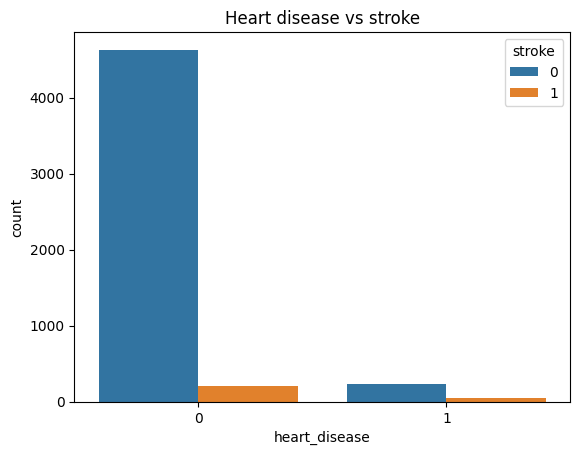

In [13]:
sns.countplot(data=df, x='heart_disease', hue='stroke')
plt.title('Heart disease vs stroke')
plt.show()



## **Feature Engineering**

In [14]:
# Drop ID because it does not matter
df = df.drop(columns=['id'])

# Add bmi_category using WHO clinical bands
def bmi_band(b):
    if pd.isna(b): return 'Unknown'
    if b < 18.5:   return 'Underweight'
    if b < 25:     return 'Normal'
    if b < 30:     return 'Overweight'
    return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_band)

print(df['bmi_category'].value_counts())
df.head()

bmi_category
Obese          1920
Overweight     1409
Normal         1243
Underweight     337
Unknown         201
Name: count, dtype: int64


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Unknown
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Obese
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Normal


In [15]:
#drop the BMI column because we will use the categorical one
df = df.drop(columns=['bmi'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke,bmi_category
0,Male,67.0,0,1,Yes,Private,Urban,228.69,formerly smoked,1,Obese
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,never smoked,1,Unknown
2,Male,80.0,0,1,Yes,Private,Rural,105.92,never smoked,1,Obese
3,Female,49.0,0,0,Yes,Private,Urban,171.23,smokes,1,Obese
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,never smoked,1,Normal


## **Train Test Split**

In [16]:

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['stroke'] #we used stratify because there is class imbalance
)

print(f"Train: {train_df.shape}  positives: {train_df['stroke'].sum()}")
print(f"Test:  {test_df.shape}  positives: {test_df['stroke'].sum()}")

Train: (4088, 11)  positives: 199
Test:  (1022, 11)  positives: 50


## **Training And Evaluation**

In [17]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(
    label='stroke', #Target
    eval_metric='roc_auc', #right metric for imbalanced data
    problem_type='binary' # 0 or 1 prediction
).fit(
    train_df,
    time_limit=300, # 5 min training limit
    presets='medium_quality'
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260505_214703"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.97 GB / 12.67 GB (86.6%)
Disk Space Avail:   64.77 GB / 112.64 GB (57.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/AutogluonModels/ag-20260505_214703"
Train Data Rows:    4088
Train Data Columns: 10
Label Column:       stroke
Problem Type:       binary
Preprocessing data ...
Selected class

In [18]:
# Per model leaderboard on the test set
predictor.leaderboard(test_df, silent=True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost,0.842932,0.777574,roc_auc,0.006076,0.003184,3.027899,0.006076,0.003184,3.027899,1,True,5
1,NeuralNetTorch,0.836749,0.763130,roc_auc,0.017663,0.013478,13.513570,0.017663,0.013478,13.513570,1,True,10
2,XGBoost,0.819712,0.767595,roc_auc,0.014244,0.006383,0.598135,0.014244,0.006383,0.598135,1,True,9
3,LightGBMXT,0.809568,0.780900,roc_auc,0.006976,0.004405,5.281939,0.006976,0.004405,5.281939,1,True,1
4,WeightedEnsemble_L2,0.805967,0.808911,roc_auc,0.153044,0.103823,7.959712,0.002029,0.000502,0.053659,2,True,12
5,NeuralNetFastAI,0.804136,0.808036,roc_auc,0.029369,0.015642,6.965043,0.029369,0.015642,6.965043,1,True,8
6,LightGBMLarge,0.803467,0.728291,roc_auc,0.006813,0.003435,0.773359,0.006813,0.003435,0.773359,1,True,11
7,LightGBM,0.802510,0.777398,roc_auc,0.004081,0.004292,0.641712,0.004081,0.004292,0.641712,1,True,2
8,RandomForestGini,0.802459,0.753020,roc_auc,0.135874,0.088668,2.093564,0.135874,0.088668,2.093564,1,True,3
9,RandomForestEntr,0.793179,0.740021,roc_auc,0.122005,0.088954,1.143948,0.122005,0.088954,1.143948,1,True,4


In [19]:
# metrics on the test set
perf = predictor.evaluate(test_df)
print(perf)

{'roc_auc': np.float64(0.8059670781893005), 'accuracy': 0.9510763209393346, 'balanced_accuracy': np.float64(0.5), 'mcc': 0.0, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Here we take the max probability and min probability and mean so we know how to choose our threshlod

Our **Goal** here is to achieve the maximum recall posaible

## **Choosing the Threshold**

In [20]:
# Get probability of stroke for each test patient
probability = predictor.predict_proba(test_df)
print(probability.head())
print(f"\nMin prob of stroke: {probability[1].min():.4f}")
print(f"Max prob of stroke: {probability[1].max():.4f}")
print(f"Mean prob of stroke: {probability[1].mean():.4f}")

             0         1
3725  0.970227  0.029773
4481  0.972125  0.027875
1545  0.998726  0.001274
1820  0.997206  0.002794
1262  0.926791  0.073209

Min prob of stroke: 0.0006
Max prob of stroke: 0.4911
Mean prob of stroke: 0.0411


That is why we predicted `0` strokes in the test because the threshold was `0.5` and max probability is `0.49`

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_test = test_df['stroke']
proba_pos = probability[1]   # probability of stroke=1

print(f"{'thresh':>8} {'precision':>10} {'recall':>8} {'f1':>6} {'flagged':>8}")
print("-" * 46)
for t in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]:
    preds = (proba_pos >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    flagged = preds.sum()
    print(f"{t:>8.2f} {p:>10.3f} {r:>8.3f} {f:>6.3f} {flagged:>8d}")

  thresh  precision   recall     f1  flagged
----------------------------------------------
    0.05      0.139    0.740  0.234      266
    0.08      0.170    0.600  0.265      176
    0.10      0.191    0.500  0.276      131
    0.12      0.182    0.360  0.242       99
    0.15      0.213    0.260  0.234       61
    0.20      0.250    0.140  0.179       28
    0.25      0.200    0.060  0.092       15
    0.30      0.125    0.020  0.034        8


**Decision threshold**

We turn the model's stroke probability into a clinical action by applying a threshold:

- **Threshold = 0.08 (chosen):** flag any patient with `prob ≥ 0.08` for follow-up. Catches ~60% of stroke patients, flags ~17% of all patients, precision ~17%.
- **Threshold = 0.05 (high-sensitivity alternative):** use this if "missing a stroke is unacceptable." Catches ~74% of stroke patients, flags ~26% of all patients, precision ~14%.

The threshold is a deployment time decision and can be tuned per clinical workflow.

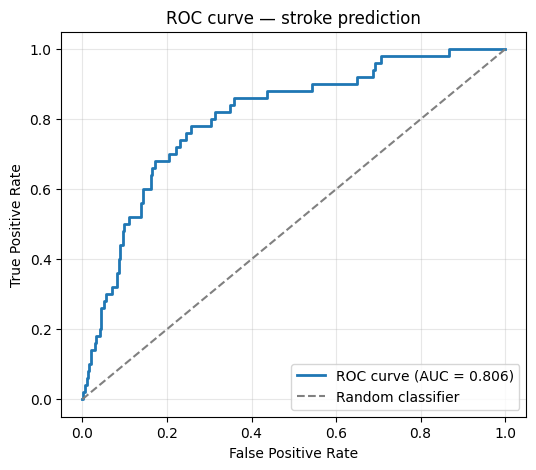

In [26]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, proba_pos)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve — stroke prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

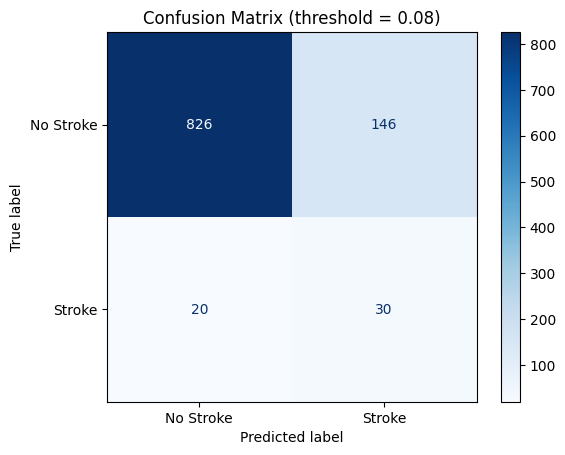

True negatives:  826  (correctly identified as no-stroke)
False positives: 146  (flagged but didn't have stroke)
False negatives: 20  (missed strokes)
True positives:  30  (correctly flagged strokes)


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.08
preds_at_threshold = (proba_pos >= threshold).astype(int)

cm = confusion_matrix(y_test, preds_at_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (threshold = {threshold})')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}  (correctly identified as no-stroke)")
print(f"False positives: {fp}  (flagged but didn't have stroke)")
print(f"False negatives: {fn}  (missed strokes)")
print(f"True positives:  {tp}  (correctly flagged strokes)")

---

## **Feature Importance**

In [22]:
predictor.feature_importance(test_df)

Computing feature importance via permutation shuffling for 10 features using 1022 rows with 5 shuffle sets...
	8.78s	= Expected runtime (1.76s per shuffle set)
	2.32s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
age,0.264588,0.026082,0.000011,5,0.318292,0.210885
avg_glucose_level,0.018568,0.009617,0.006238,5,0.038370,-0.001234
ever_married,0.014461,0.008438,0.009291,5,0.031834,-0.002913
bmi_category,0.005794,0.003554,0.010929,5,0.013112,-0.001524
work_type,0.002852,0.005020,0.136430,5,0.013189,-0.007485
smoking_status,0.000477,0.002872,0.364497,5,0.006391,-0.005436
gender,-0.001263,0.002491,0.839972,5,0.003865,-0.006392
heart_disease,-0.003934,0.001940,0.994730,5,0.000060,-0.007928
hypertension,-0.004609,0.002429,0.993384,5,0.000392,-0.009610
Residence_type,-0.005041,0.007334,0.900446,5,0.010060,-0.020142


In [23]:
# Build a single new patient as a one-row DataFrame
new_patient = pd.DataFrame([{
    'gender': 'Male',
    'age': 67,
    'hypertension': 1,
    'heart_disease': 0,
    'ever_married': 'Yes',
    'work_type': 'Private',
    'Residence_type': 'Urban',
    'avg_glucose_level': 180.5,
    'smoking_status': 'formerly smoked',
    'bmi_category': 'Obese',
}])

# Probability of stroke
prob = predictor.predict_proba(new_patient)[1].iloc[0]
print(f"Stroke probability: {prob:.4f}")
print(f"Decision at threshold 0.08: {'FLAG for follow-up' if prob >= 0.08 else 'routine care'}")

Stroke probability: 0.1433
Decision at threshold 0.08: FLAG for follow-up


In [24]:
# Where AutoGluon saved the model during fit()
save_path = predictor.path
print(f"Model saved at: {save_path}")

# Reload the saved model from disk
loaded_predictor = TabularPredictor.load(save_path)

# Verify it produces the same prediction as the live predictor
prob_loaded = loaded_predictor.predict_proba(new_patient)[1].iloc[0]
print(f"Live model prob:   {prob:.4f}")
print(f"Loaded model prob: {prob_loaded:.4f}")
print("Match!" if abs(prob - prob_loaded) < 1e-9 else "MISMATCH")

Model saved at: /content/AutogluonModels/ag-20260505_214703
Live model prob:   0.1433
Loaded model prob: 0.1433
Match!


In [25]:
import shutil
from google.colab import files

zip_path = shutil.make_archive('autogluon_model', 'zip', save_path)
print(f"Created: {zip_path}")
files.download('autogluon_model.zip')

Created: /content/autogluon_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>